In [183]:
import duckdb
import re
import matplotlib.pyplot as plt
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    #'text.usetex': True,
    'pgf.rcfonts': False,   # Fuente con serifa para coherencia con el texto
    "font.size": 11,          # Tamaño base
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 14,
    #"axes.titleweight": "bold",
    "grid.alpha": 0.1         # Rejilla más sutil
})
def get_afiliados_grupos(grupos, file_path="../data/silver/MUNCNAE1221.csv"):
    # Conectamos a una instancia en memoria
    con = duckdb.connect(database=':memory:')
    
    # Preparamos las agregaciones dinámicas para los grupos
    group_queries = []
    for g in grupos:
        label = re.sub(r'[^a-zA-Z0-9_]', '_', g['label'].lower())
        label = g['label']
        codes = tuple(g['codes']) # SQL necesita tuplas para el operador IN
        
        group_queries.append(f"""
            SUM(CASE WHEN cod_cnae IN {codes} THEN afiliados ELSE 0 END) AS 'total_{label}',
            SUM(CASE WHEN cod_cnae IN {codes} AND sexo = 'VARON' THEN afiliados ELSE 0 END) AS 'hombres_{label}',
            SUM(CASE WHEN cod_cnae IN {codes} AND sexo = 'MUJER' THEN afiliados ELSE 0 END) AS 'mujeres_{label}',
            SUM(CASE WHEN cod_cnae IN {codes} AND cod_regimen = 111 THEN afiliados ELSE 0 END) AS 'reg_cta_ajena_{label}',
            SUM(CASE WHEN cod_cnae IN {codes} AND cod_regimen = 521 THEN afiliados ELSE 0 END) AS 'reg_cta_propia_{label}'
            -- Añade aquí las combinaciones cruzadas si las necesitas
        """)

    # Construimos la query principal
    query = f"""
        SELECT 
            cod_municipio AS cmun,
            YEAR(CAST(fecha AS DATE)) AS anno,
            SUM(afiliados) AS total_afiliados,
            SUM(CASE WHEN sexo = 'VARON' THEN afiliados ELSE 0 END) AS hombres_afiliados,
            SUM(CASE WHEN sexo = 'MUJER' THEN afiliados ELSE 0 END) AS mujeres_afiliadas,
            SUM(CASE WHEN cod_regimen = 111 THEN afiliados ELSE 0 END) AS reg_cta_ajena_afiliados,
            SUM(CASE WHEN cod_regimen = 521 THEN afiliados ELSE 0 END) AS reg_cta_propia_afiliados,
            {", ".join(group_queries)}
        FROM read_csv('{file_path}', sep=';', header=True, auto_detect=True)
        GROUP BY cmun, anno
    """
    
    # Ejecutamos y convertimos de vuelta a Pandas solo al final
    return con.execute(query).df()

In [184]:
import duckdb
import json
import pandas as pd
def query(query_str):
    return duckdb.query(query_str).to_df()
empresas_df = pd.read_parquet("../data/silver/iberinform_startups_certificadas.parquet", engine='pyarrow')
empresas_df['anno_constitucion'] = pd.to_datetime(
    empresas_df['fecha_constitucion'], errors='coerce').dt.year
top10_grupos = query(
    """
        SELECT
        grupo_cnae,
        descripcion_grupo_cnae,
        COUNT(*) AS startups
        FROM empresas_df
        WHERE anno_constitucion BETWEEN 2021 AND 2024
        GROUP BY grupo_cnae, descripcion_grupo_cnae
        ORDER BY startups DESC;
    """
).head(10).set_index('descripcion_grupo_cnae')['grupo_cnae'].to_dict()
print(json.dumps(top10_grupos, indent=4, ensure_ascii=False))

{
    "Programación, consultoría y otras actividades relacionadas con la informática": "62",
    "Servicios técnicos de arquitectura e ingeniería; ensayos y análisis técnicos": "71",
    "Comercio al por menor": "47",
    "Investigación y desarrollo": "72",
    "Actividades de las sedes centrales y consultoría de gestión empresarial": "70",
    "Comercio al por mayor": "46",
    "Actividades de publicidad, estudios de mercado, relaciones públicas y comunicación": "73",
    "Educación": "85",
    "Otras actividades profesionales, científicas y técnicas": "74",
    "Industria alimentaria": "10"
}


In [185]:
# Definimos los grupos de CNAE para el análisis de afiliados
grupos_l2 = [
    { 'label': '46' ,'legend': 'Wholesale', 'codes': ['46']},
    { 'label': '47' ,'legend': 'Retail', 'codes': ['47']},
    { 'label': '62' ,'legend': 'Software', 'codes': ['62']},
    { 'label': '10' ,'legend': 'Ind. Alimentaria', 'codes': ['10']},
    { 'label': '70' ,'legend': 'Consultoría', 'codes': ['70']},
    { 'label': '71' ,'legend': 'Arquitectura/Ingenieria', 'codes': ['71']},
    { 'label': '72' ,'legend': 'I+D', 'codes': ['72']},
    { 'label': '73' ,'legend': 'Marketing', 'codes': ['73']},
    { 'label': '74' ,'legend': 'Otros servicios profesionales', 'codes': ['74']},
    { 'label': '85', 'legend': 'Educación', 'codes': ['85']}
]


In [186]:
afiliados_l2 = pd.concat([get_afiliados_grupos(grupos=grupos_l2, file_path=f"../data/silver/MUNCNAE12{year}.csv") for year in range(20, 25)], ignore_index=True)
municipios_df = pd.read_csv("../data/silver/municipios.csv", sep=",", dtype=str)
municipios_df['codigo_municipio'] = municipios_df['cpro'] + municipios_df['cmun']
municipios_dict = municipios_df.set_index('codigo_municipio')['nombre'].to_dict()
provincias_df = pd.read_csv("../data/silver/ine_ccaa_y_provincias.csv", sep=";", dtype=str)
provincias_dict = provincias_df.set_index('cpro')['provincia'].to_dict()
ccaa_dict = provincias_df.set_index('cpro')['comunidad_autonoma'].to_dict()
ccaa_cod_dict = provincias_df.set_index('cpro')['codauto'].to_dict()

afiliados_l2['municipio'] = afiliados_l2['cmun'].map(municipios_dict)
afiliados_l2['cpro'] = afiliados_l2['cmun'].str[:2]
afiliados_l2['provincia'] = afiliados_l2['cpro'].map(provincias_dict)
afiliados_l2['ccaa'] = afiliados_l2['cpro'].map(ccaa_cod_dict)
afiliados_l2['comunidad_autonoma'] = afiliados_l2['cpro'].map(ccaa_dict)


prefixes = ['total', 'hombres', 'mujeres', 'reg_cta_ajena', 'reg_cta_propia']

cols = [ col for col in afiliados_l2.columns if any(col.startswith(prefix) for prefix in prefixes)]

afiliados_provincial_l2 = afiliados_l2.groupby(['provincia', 'cpro', 'anno'])[cols].sum().reset_index().copy()


In [187]:
afiliados_provincial_l2.to_csv('../data/gold/afiliados_provincial.csv', sep=';', index=False)

In [188]:
af_l2_2024 = afiliados_provincial_l2.query("anno == 2024").copy().sort_values('cpro').reset_index(drop=True)
af_l2_2021 = afiliados_provincial_l2.query("anno == 2020").copy().sort_values('cpro').reset_index(drop=True)
af_l2_2024_indexado = af_l2_2024.set_index(['cpro', 'provincia'])
af_l2_2021_indexado = af_l2_2021.set_index(['cpro', 'provincia'])

af_l2 = af_l2_2024_indexado[cols] - af_l2_2021_indexado[cols]
af_l2.reset_index(inplace=True)

In [189]:
empresas_df = pd.read_parquet("../data/silver/iberinform_startups_certificadas.parquet", engine='pyarrow')
municipios_df = pd.read_csv("../data/silver/municipios.csv", sep=",", dtype=str)
municipios_df['cmuni'] = municipios_df['cpro']+municipios_df['cmun']
dict_municipios_cmun = municipios_df.set_index('nombre')['cmuni'].to_dict()
cpro_ccaa_df = pd.read_csv("../data/silver/ine_ccaa_y_provincias.csv", sep=";", dtype=str)
dict_cpro_provincia = cpro_ccaa_df.set_index('cpro')['provincia'].to_dict()
dict_cpro_ccaa = cpro_ccaa_df.set_index('cpro')['codauto'].to_dict()
empresas_df['anno_constitucion'] = pd.to_datetime(
    empresas_df['fecha_constitucion'], errors='coerce').dt.year
empresas_df['cpro'] = empresas_df['codigo_postal'].str[:2]
empresas_df['ccaa'] = empresas_df['cpro'].map(dict_cpro_ccaa)
poblacion_df = pd.read_parquet("../data/silver/poblacion_2024.parquet", engine='pyarrow')
poblacion_provincial_df = poblacion_df.groupby(['cpro']).agg(
    poblacion=('poblacion', 'sum'),
    hombres=('hombres', 'sum'),
    mujeres=('mujeres', 'sum') 
).reset_index()
poblacion_provincial_df['provincia'] = poblacion_provincial_df['cpro'].map(dict_cpro_provincia)


provincia_startups_df = query(
    """
    PIVOT (
    -- 1. Preparamos los datos filtrados y calculamos el total por provincia
    SELECT 
        provincia,
        cpro,
        grupo_cnae,
        COUNT(*) OVER (PARTITION BY provincia) AS startups
    FROM empresas_df 
    WHERE anno_constitucion BETWEEN 2021 AND 2024
) 
-- 2. Definimos que los nombres de las columnas serán los grupos CNAE
ON grupo_cnae 

-- 3. La métrica a contar es el número de startups por cada cruce
USING COUNT(*) 

-- 4. Agrupamos por provincia y mantenemos el total que calculamos antes
GROUP BY 
    provincia, cpro,
    startups
ORDER BY 
    startups DESC;
    """)
provincia_startups_df.drop(columns=['provincia'], inplace=True)
provincia_startups_df = poblacion_provincial_df[['cpro','provincia', 'poblacion', 'hombres', 'mujeres']].merge(provincia_startups_df, on='cpro', how='left').fillna(0)

provincia_startups_df['startups_no_IT'] = provincia_startups_df['startups'] - provincia_startups_df['62'] - provincia_startups_df['63']

In [190]:
startups_af_df = provincia_startups_df.merge(af_l2, on=['cpro','provincia'], how='left')

In [191]:

nuevas_cols = {}

for grupo in grupos_l2:
    label = grupo['label']
    legend = grupo['legend']
    startups_af_df[f' ({label}){legend}'] = (startups_af_df[label] / startups_af_df['poblacion'] * 100000)
    nuevas_cols[f'({label}){legend}'] = startups_af_df[f'total_{label}'] / startups_af_df['poblacion'] * 100000
    #nuevas_cols[f'Autónomos {legend} /100K hab'] = startups_af_df[f'reg_cta_propia_{label}'] / startups_af_df['poblacion'] * 100000
    #nuevas_cols[f'Asalariados {legend} /100K hab'] = startups_af_df[f'reg_cta_ajena_{label}'] / startups_af_df['poblacion'] * 100000
# construir dataframe con mismo índice (IMPORTANTE)
nuevas_df = pd.DataFrame(nuevas_cols, index=startups_af_df.index)

# añadir de golpe
startups_af_df = pd.concat([startups_af_df, nuevas_df], axis=1)

startups_af_df['Startups'] = (startups_af_df['startups'] / startups_af_df['poblacion'] * 100000)
startups_af_df['Startups no IT'] = (startups_af_df['startups_no_IT'] / startups_af_df['poblacion'] * 100000)

In [192]:
grupos_l2

[{'label': '46', 'legend': 'Wholesale', 'codes': ['46']},
 {'label': '47', 'legend': 'Retail', 'codes': ['47']},
 {'label': '62', 'legend': 'Software', 'codes': ['62']},
 {'label': '10', 'legend': 'Ind. Alimentaria', 'codes': ['10']},
 {'label': '70', 'legend': 'Consultoría', 'codes': ['70']},
 {'label': '71', 'legend': 'Arquitectura/Ingenieria', 'codes': ['71']},
 {'label': '72', 'legend': 'I+D', 'codes': ['72']},
 {'label': '73', 'legend': 'Marketing', 'codes': ['73']},
 {'label': '74', 'legend': 'Otros servicios profesionales', 'codes': ['74']},
 {'label': '85', 'legend': 'Educación', 'codes': ['85']}]

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns
def plot_correlation(df_norm, feature_cols,feature_label, target_cols, target_label, title, save_as=None):
    """Genera el heatmap optimizado"""
    corr = df_norm[target_cols + feature_cols].corr(method='spearman').loc[target_cols, feature_cols]
    corr.drop_duplicates(inplace=True)
    plt.figure(figsize=(16, 10))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, 
                fmt=".2f", linewidths=.5, cbar_kws={"shrink": .8})
    
    plt.title(title, fontsize=16, pad=20)
    plt.ylabel(target_label, fontsize=12, labelpad=10)
    plt.xlabel(feature_label, fontsize=12, labelpad=10)
    plt.yticks(rotation=0, va='center')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, format='pdf', bbox_inches='tight', pad_inches=0.1)
    plt.show()

In [194]:
#target_cols = set()
#feature_cta_propia_cols = set()
feature_cta_propia_100k_cols = set()
#feature_cta_ajena_cols = set()
feature_cta_ajena_100k_cols = set()
#feature_afiliados_cols = set()
feature_afiliados_100k_cols = set()
#feature_afiliados_hombres_100k_cols = set()
#feature_afiliados_mujeres_100k_cols = set()
#feature_afiliados_hombres_cols = set()
#feature_afiliados_mujeres_cols = set()
#feature_brecha_cols = set()
#feature_diff_h_m_100k_cols = set()
target_100k_cols = set()
label_dict = {}
for grupo in grupos_l2:
    label = grupo['label']
    legend = grupo['legend']
    #feature_cta_propia_cols.add(f'%reg_cta_propia_{label}')
    feature_cta_propia_100k_cols.add(f'Autónomos {legend} /100K hab')
    #feature_cta_ajena_cols.add(f'%reg_cta_ajena_{label}')
    feature_cta_ajena_100k_cols.add(f'Asalariados {legend} /100K hab')
    #feature_afiliados_cols.add(f'%{label}')
    feature_afiliados_100k_cols.add(f'({label}){legend}')
    #feature_afiliados_hombres_cols.add(f'%hombres_{label}')
    #feature_afiliados_hombres_100k_cols.add(f'hombres {legend} /100K hab')
    #feature_afiliados_mujeres_cols.add(f'%mujeres_{label}')
    #feature_afiliados_mujeres_100k_cols.add(f'mujeres {legend} /100K hab')
    #feature_brecha_cols.add(f'%brecha_{label}')
    #feature_diff_h_m_100k_cols.add(f'diff_h_m_{label} /100K hab')
    #target_cols.update(label.split('_')) if '_' in label else target_cols.add(label)
    target_100k_cols.add(f' ({label}){legend}')
    #label_dict[f'%{label}'] = legend

In [195]:
#feature_cta_propia_cols = sorted(feature_cta_propia_cols)
feature_cta_propia_100k_cols = sorted(feature_cta_propia_100k_cols)
#feature_cta_ajena_cols = sorted(feature_cta_ajena_cols)
feature_cta_ajena_100k_cols = sorted(feature_cta_ajena_100k_cols)
#feature_afiliados_cols = sorted(feature_afiliados_cols)
feature_afiliados_100k_cols = sorted(feature_afiliados_100k_cols)
#feature_afiliados_hombres_cols = sorted(feature_afiliados_hombres_cols)
#feature_afiliados_hombres_100k_cols = sorted(feature_afiliados_hombres_100k_cols)
#feature_afiliados_mujeres_cols = sorted(feature_afiliados_mujeres_cols)
#feature_afiliados_mujeres_100k_cols = sorted(feature_afiliados_mujeres_100k_cols)
#feature_brecha_cols = sorted(feature_brecha_cols)
#feature_diff_h_m_100k_cols = sorted(feature_diff_h_m_100k_cols)
target_100k_cols = sorted(target_100k_cols)
#target_cols = sorted(target_cols)


In [196]:
startups_af_df['startups'].describe()

count     52.000000
mean      26.903846
std       67.799086
min        0.000000
25%        4.000000
50%        8.500000
75%       20.000000
max      372.000000
Name: startups, dtype: float64

In [197]:
startups_af_df_75 = startups_af_df[(startups_af_df['startups'] > 27)]
print(startups_af_df_75.shape[0])
startups_af_df_iqr = startups_af_df[(startups_af_df['startups'] <= 27) & (startups_af_df['startups'] > 5)]
print(startups_af_df_iqr.shape[0])
startups_af_df_25 = startups_af_df[(startups_af_df['startups'] <= 5)]
print(startups_af_df_25.shape[0])

10
23
19


# Correlación entre creación de empleo y creación de startups según grupo de actividad económica (2021-2024)

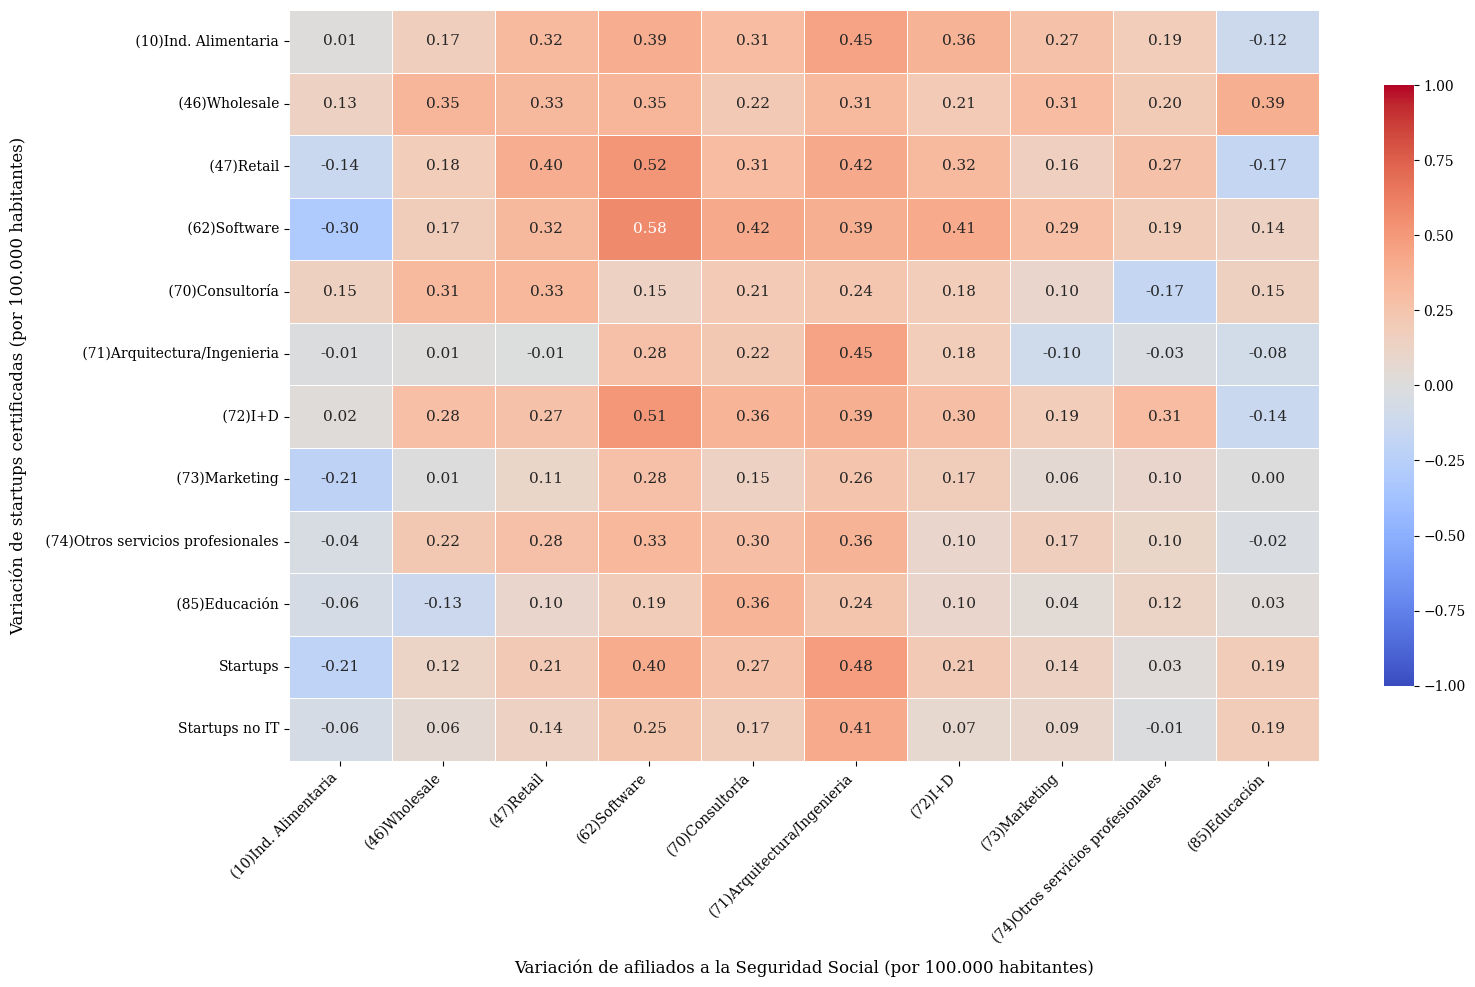

In [198]:
agregados_100k = ['Startups', 'Startups no IT']
title = "Correlación entre Proporción de Afiliados y Grupos CNAE en Provincias 2024 (total muestra)"

plot_correlation(startups_af_df, list(feature_afiliados_100k_cols), "Variación de afiliados a la Seguridad Social (por 100.000 habitantes)", list(
    target_100k_cols)+agregados_100k,
    "Variación de startups certificadas (por 100.000 habitantes)", "")#, save_as="../docs/manuscrito/recursos/figuras/matriz-corr-startups-afiliados-2021-2024.pdf")

## alternativa solo provincias superiores al percentil 75

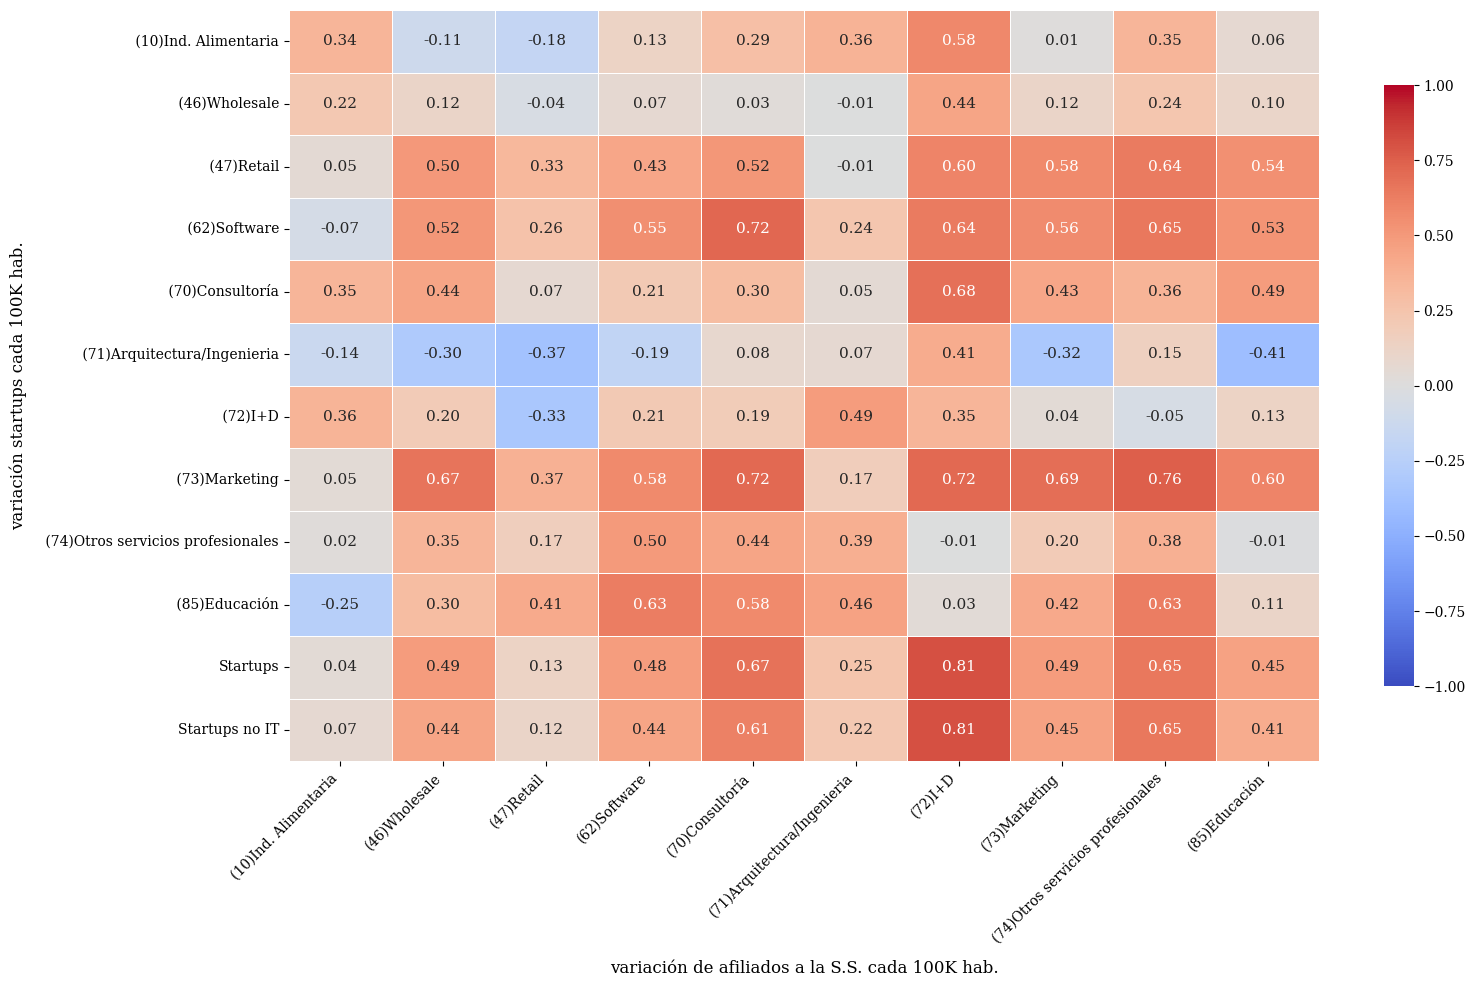

In [199]:
agregados_100k = ['Startups', 'Startups no IT']
plot_correlation(startups_af_df_75, list(feature_afiliados_100k_cols), "variación de afiliados a la S.S. cada 100K hab.", list(
    target_100k_cols)+agregados_100k,
    "variación startups cada 100K hab.", "")

# Composición de mano de obra cualificada

In [200]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

def graficar_vecinos_radar_latex(df, target_nivel, columnas_sectores, n_vecinos=4, anno=2024, nivel='provincia', min_afiliados=1000, exportar_latex=True):
    """
    Agrupa datos, encuentra vecinos KNN, dibuja gráfico y genera código LaTeX.
    """

    # 1. Agrupación dinámica
    agg_dict = {'total_afiliados': 'sum'}
    for columna in columnas_sectores:
        agg_dict[columna['column']] = 'sum'

    df_agrupado_previo = df.groupby([nivel, 'anno']).agg(agg_dict).reset_index()
    df_agrupado = df_agrupado_previo[df_agrupado_previo['total_afiliados'] >= min_afiliados]
    
    # 2. Filtrar por año
    df_filtro = df_agrupado[df_agrupado['anno'] == anno].copy()
    df_filtro = df_filtro.reset_index(drop=True)

    if target_nivel not in df_filtro[nivel].values:
        raise ValueError(f"La {nivel} '{target_nivel}' no se encuentra en el año {anno}.")
    max_pct = 0
    # 3. Calcular porcentajes
    features = []
    for columna in columnas_sectores:
        col = columna['column']
        col_pct = f'{col}_%'
        df_filtro[col_pct] = (df_filtro[col] / df_filtro['total_afiliados']) * 100
        max_pct = max(max_pct, df_filtro[col_pct].max())
        features.append(col_pct)

    # 4. Escalar y aplicar KNN
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_filtro[features])

    knn = NearestNeighbors(n_neighbors=n_vecinos + 1)
    knn.fit(X_scaled)

    target_idx = df_filtro[df_filtro[nivel] == target_nivel].index[0]
    neighbor_indices = knn.kneighbors([X_scaled[target_idx]], return_distance=False)[0][1:]

    # 5. Preparar Gráfico Matplotlib
    indices_to_plot = [target_idx] + list(neighbor_indices)
    num_vars = len(features)
    etiquetas_radar = [columna['label'] for columna in columnas_sectores]
    
    # --- LÓGICA DE EXPORTACIÓN A LATEX ---
    max_pct = round(max_pct, 0)
    regresive_from_max_pct = [max_pct - (i * max_pct / 5) for i in range(6)]  # 5 niveles + 0
    if exportar_latex:
        # Calcular ángulos en grados para LaTeX (0, 60, 120...)
        angulos_grados = [int(i * 360 / num_vars) for i in range(num_vars)]
        
        latex_code = [
            "\\begin{figure}[H]",
            "\t\\centering",
            "\t\\begin{tikzpicture}",
            "\t\t\\begin{polaraxis}[",
            "\t\t\twidth=10cm,",
            f"\t\t\txtick={{{','.join(map(str, angulos_grados))}}},",
            f"\t\t\txticklabels={{{','.join(etiquetas_radar)}}},",
            f"\t\t\tymin=0, ymax={max_pct+0.5},",
            f"\t\t\tytick={{{','.join(map(str, regresive_from_max_pct))}}},",
            "\t\t\tylabel near ticks,",
            "\t\t\tlegend pos=outer north east,",
            "\t\t]"
        ]

        colores_latex = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']

        for i, idx in enumerate(indices_to_plot):
            region_name = df_filtro.iloc[idx][nivel]
            valores = df_filtro.iloc[idx][features].values.tolist()
            # Añadir el primer valor al final para cerrar el polígono
            valores_plot = valores + [valores[0]]
            angulos_plot = angulos_grados + [360]
            
            # Formatear coordenadas: (ang, val) (ang, val)...
            coords = " ".join([f"({a},{v:.2f})" for a, v in zip(angulos_plot, valores_plot)])
            
            color = colores_latex[i % len(colores_latex)]
            # CAMBIAR ESTA LÍNEA:
            style = "thick, fill opacity=0.2" 
            if i == 0: 
                style += ", fill=" + color #
            
            latex_code.append(f"\t\t\t% {region_name}")
            latex_code.append(f"\t\t\t\\addplot[{color}, {style}] coordinates {{")
            latex_code.append(f"\t\t\t\t{coords}")
            latex_code.append("\t\t\t};")
            latex_code.append(f"\t\t\t\\addlegendentry{{{region_name}}}")

        latex_code.extend([
            "       \\end{polaraxis}",
            "   \\end{tikzpicture}",
            f"  \\caption{{Comparativa sectorial: {target_nivel} vs vecinos ({anno})}}",
            f"  \\label{{fig:radar_{target_nivel.lower()}}}",
            "\\end{figure}"
        ])
        
        print("\n%%% CÓDIGO LATEX GENERADO %%%\n")
        print("\n".join(latex_code))
        print("\n%%%%%%%%%%%%%%%%%%%%%%%%%%%%%\n")

    # 6. Gráfico en Matplotlib (opcional, se mantiene para visualización rápida)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    
    for i, idx in enumerate(indices_to_plot):
        region_name = df_filtro.iloc[idx][nivel]
        valores = df_filtro.iloc[idx][features].values.tolist()
        valores += valores[:1]
        ax.plot(angles, valores, label=region_name, linewidth=2 if i==0 else 1)
        if i == 0: 
            ax.fill(angles, valores, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(etiquetas_radar)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()


columnas_cta_ajena = [
    #{'column': 'total_10', 'label': 'Industria alimentaria (C)'},
    {'column': 'reg_cta_ajena_70', 'label': 'Consultoria (N)'},
    {'column': 'reg_cta_ajena_73', 'label': 'Publicidad (N)'},
    {'column': 'reg_cta_ajena_63', 'label': 'infra IT (K)'},
    {'column': 'reg_cta_ajena_62', 'label': 'informática (K)'},
    {'column': 'reg_cta_ajena_71', 'label': 'Arquitectura e ingeniería (N)'},
    {'column': 'reg_cta_ajena_72', 'label': 'I+D (N)'},
    #{'column': 'total_46', 'label': 'Com. Al por mayor (G)'},
    #{'column': 'total_47', 'label': 'Com. Al por menor (G)'},
]
columnas_cta_propia = [
    #{'column': 'total_10', 'label': 'Industria alimentaria (C)'},
    {'column': 'reg_cta_propia_70', 'label': 'Consultoria (N)'},
    {'column': 'reg_cta_propia_73', 'label': 'Publicidad (N)'},
    {'column': 'reg_cta_propia_63', 'label': 'infra IT (K)'},
    {'column': 'reg_cta_propia_62', 'label': 'informática (K)'},
    {'column': 'reg_cta_propia_71', 'label': 'Arquitectura e ingeniería (N)'},
    {'column': 'reg_cta_propia_72', 'label': 'I+D (N)'},
    #{'column': 'total_46', 'label': 'Com. Al por mayor (G)'},
    #{'column': 'total_47', 'label': 'Com. Al por menor (G)'},
]
columnas = [
    #{'column': 'total_10', 'label': 'Industria alimentaria (C)'},
    
    #{'column': 'total_63', 'label': 'infra IT (K)'},
    {'column': 'total_72', 'label': 'I+D (N)'},
    {'column': 'total_62', 'label': 'Software (K)'},
    {'column': 'total_71', 'label': 'Arquitectura e ingeniería (N)'},
    {'column': 'total_70', 'label': 'Consultoria (N)'},
    {'column': 'total_73', 'label': 'Marketing (N)'},
    #{'column': 'total_46', 'label': 'Com. Al por mayor (G)'},
    #{'column': 'total_47', 'label': 'Com. Al por menor (G)'},
]

Provincias similares a Madrid

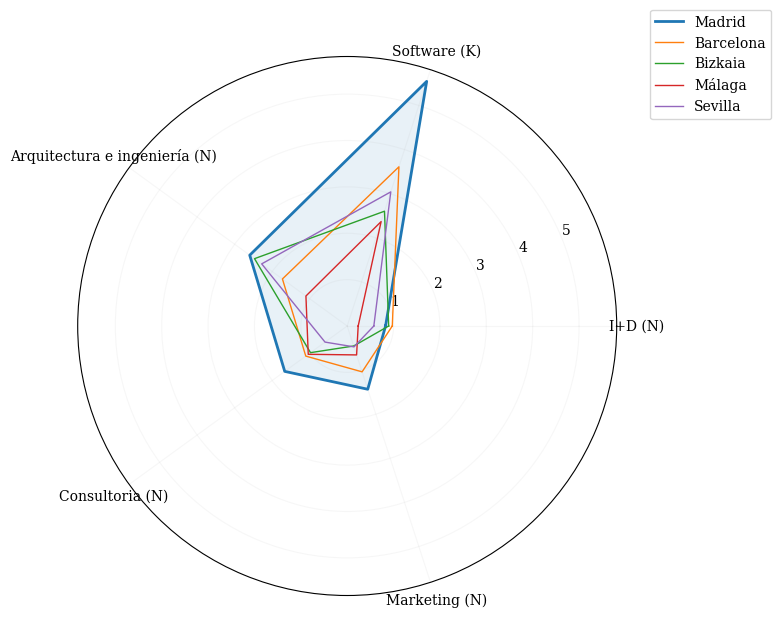

In [201]:

#graficar_vecinos_radar(af_l2_2024, target_nivel='Madrid', columnas_sectores=columnas, n_vecinos=4, anno=2024, nivel='provincia', min_afiliados=1000)
graficar_vecinos_radar_latex(af_l2_2024, target_nivel='Madrid', columnas_sectores=columnas, n_vecinos=4, anno=2024, nivel='provincia', min_afiliados=1000, exportar_latex=False)
#graficar_vecinos_radar_latex(af_l2_2024, target_nivel='Barcelona', columnas_sectores=columnas, n_vecinos=4, anno=2024, nivel='provincia', min_afiliados=1000, exportar_latex=True)

# Correlación entre creación de startups y similitud/distancia de la composición de la mano de obra líder

Bajo la premisa de que la composición de la mano de obra cualificada influye en la creación de startups, se crea una grafica de dispersión para compobar la correlación de spaerman entre similitud al lider (Madrid) y creación de startups.

In [202]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import numpy as np

def calcular_similitud_estructural(df, target_provincia, columnas_sectores, nivel='provincia', col_total='total_afiliados'):
    """
    Calcula la distancia euclídea de cada fila respecto a un objetivo (benchmark)
    calculando dinámicamente el % de cada sector sobre el total.
    """
    # 1. Copia de seguridad
    temp_df = df.copy()
    
    # 2. Calcular porcentajes dinámicamente
    features = []
    for columna in columnas_sectores:
        col = columna['column']
        col_pct = f'{col}_%'
        
        # Calcular porcentaje respecto al total
        temp_df[col_pct] = (temp_df[col] / temp_df[col_total]) * 100
        features.append(col_pct)
        
    # 3. Limpieza de seguridad
    # Reemplazar posibles infinitos (si el total era 0) por NaN para que dropna los elimine
    temp_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    temp_df.dropna(subset=features + [nivel, col_total], inplace=True)
    
    # 4. Escalado de las variables (Crucial para que la distancia sea justa)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(temp_df[features])
    
    # 5. Identificar el vector del 'Líder' (Benchmark)
    # Reseteamos el índice de la búsqueda para evitar problemas si dropna eliminó filas previas
    try:
        target_idx = temp_df.reset_index(drop=True)[temp_df.reset_index(drop=True)[nivel] == target_provincia].index[0]
        vector_lider = X_scaled[target_idx].reshape(1, -1)
    except IndexError:
        raise ValueError(f"La {nivel} '{target_provincia}' no se encuentra o fue eliminada por datos nulos.")

    # 6. Calcular distancias euclídeas de todos contra el líder
    distancias = pairwise_distances(X_scaled, vector_lider, metric='euclidean').flatten()
    
    # 7. Añadir al DataFrame original (o al temporal limpio)
    temp_df['distancia_al_lider'] = distancias
    
    # Opcional: Crear grado de similitud (Inversa de la distancia)
    # Usamos 1 / (1 + dist) para normalizar entre 0 (nada similar) y 1 (idéntico)
    temp_df['grado_similitud'] = 1 / (1 + temp_df['distancia_al_lider'])
    
    return temp_df

datos de 2024

In [203]:
# Calculamos
provincia_startups_2024 = query(
    """
    PIVOT (
    -- 1. Preparamos los datos filtrados y calculamos el total por provincia
    SELECT 
        provincia,
        cpro,
        grupo_cnae,
        COUNT(*) OVER (PARTITION BY provincia) AS startups
    FROM empresas_df 
    WHERE anno_constitucion == 2024
) 
-- 2. Definimos que los nombres de las columnas serán los grupos CNAE
ON grupo_cnae 

-- 3. La métrica a contar es el número de startups por cada cruce
USING COUNT(*) 

-- 4. Agrupamos por provincia y mantenemos el total que calculamos antes
GROUP BY 
    provincia, cpro,
    startups
ORDER BY 
    startups DESC;
    """)
similitud_df = calcular_similitud_estructural(
    af_l2_2024.copy(), 
    target_provincia='Madrid', 
    columnas_sectores=columnas,
    nivel='provincia'
)
hipotesis = similitud_df.merge(provincia_startups_2024[['provincia', 'startups']], on='provincia', how='left')[['provincia', 'distancia_al_lider', 'grado_similitud', 'startups', 'cpro']].sort_values('distancia_al_lider').fillna(0)
hipotesis = hipotesis.merge(poblacion_provincial_df[['cpro', 'poblacion']], on='cpro', how='left')
# 6. Correlación final
#col_target = list(target_100k_cols)+agregados_100k


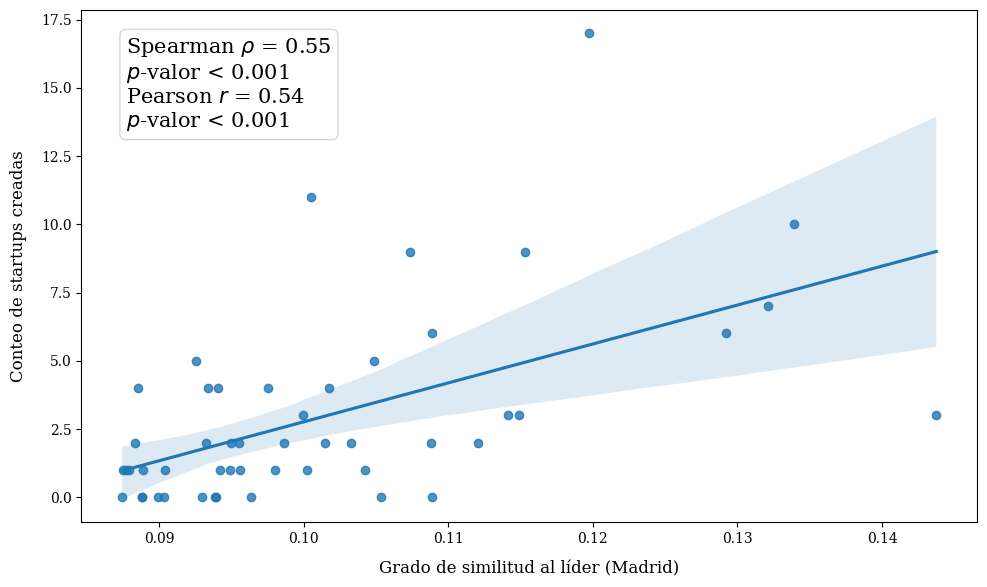

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Calcular la correlación de Spearman y el p-valor
# Asegúrate de no tener valores nulos en estas dos columnas antes de calcularlo
hipotesis_sin_madrid_barcelona = hipotesis.query('provincia not in  ["Madrid", "Barcelona"]').copy()
rho, p_value = stats.spearmanr(hipotesis_sin_madrid_barcelona['grado_similitud'], hipotesis_sin_madrid_barcelona['startups'])
r2, p_pvalue_2 = stats.pearsonr(hipotesis_sin_madrid_barcelona['grado_similitud'], hipotesis_sin_madrid_barcelona['startups'])
# Formatear el p-valor para que luzca académico si es muy cercano a cero
p_text = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"
p_text_2 = "< 0.001" if p_pvalue_2 < 0.001 else f"= {p_pvalue_2:.3f}"
stats_text = f"Spearman $\\rho$ = {rho:.2f}\n$p$-valor {p_text}\nPearson $r$ = {r2:.2f}\n$p$-valor {p_text_2}"

# 2. Configurar el estilo
#sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(10, 6))

# 3. Generar el scatterplot
startups = 'Conteo de startups creadas'
grado_de_similitud = 'Grado de similitud al líder (Madrid)'
distancia_al_lider = 'Distancia Euclídea al líder (KNN)'
hipotesis_sin_madrid_barcelona.rename(columns={'grado_similitud': grado_de_similitud, 'startups': startups, 'distancia_al_lider': distancia_al_lider}, inplace=True)
ax = sns.regplot(
    data=hipotesis_sin_madrid_barcelona, 
    x=grado_de_similitud,
    y=startups, 
    #hue=distancia_al_lider, 
    #palette='viridis', 
    #size='poblacion', 
    #sizes=(50, 400),     
    #alpha=0.9,           
    #edgecolor='white',   
    #linewidth=1
)

ax.set_xlabel(grado_de_similitud, fontsize=12, labelpad=10)
ax.set_ylabel(startups, fontsize=12, labelpad=10)

# 4. Anotaciones de Madrid y Barcelona
plt.annotate('Madrid', xy=(0, 79), xytext=(1.5, 78),
             arrowprops=dict(arrowstyle="->", color='black', lw=1.5),
             fontsize=11, fontweight='bold', color='#333333')

plt.annotate('Barcelona', xy=(3.9, 62), xytext=(5.5, 61),
             arrowprops=dict(arrowstyle="->", color='black', lw=1.5),
             fontsize=11, fontweight='bold', color='#333333')

# 5. Añadir la caja de texto con los estadísticos (Esquina inferior izquierda)
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='lightgray')
ax.text(
    0.05, 0.95,               # Coordenadas X, Y relativas al eje (de 0 a 1)
    stats_text, 
    transform=ax.transAxes,   # Usar sistema de coordenadas del propio eje
    fontsize=15, 
    verticalalignment='top', 
    bbox=props
)

# 6. Leyenda y ajustes finales
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()


plt.show()